C:\Users\Puneeth\AppData\Local\Temp\ipykernel_22176\2942005334.py:27: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[col] = pd.to_numeric(df[col], errors='ignore')



Logistic Regression - Test Set Results
Accuracy: 0.774

Classification Report:
               precision    recall  f1-score   support

           1       0.89      0.70      0.78        44
           3       0.74      0.86      0.80        37
           4       0.71      0.68      0.69        25
           5       0.73      0.89      0.80        18

    accuracy                           0.77       124
   macro avg       0.77      0.78      0.77       124
weighted avg       0.78      0.77      0.77       124



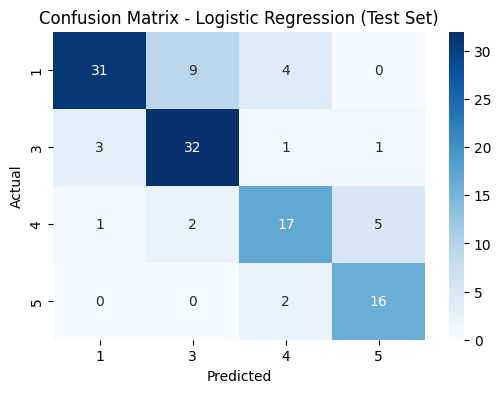

In [3]:
# =========================================
# Coral Regime - Logistic Regression (Train/Test)
# =========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# -----------------------
# 1️⃣ Load train & test datasets
# -----------------------
train_df = pd.read_csv("train.txt", sep='\t', low_memory=False)
test_df = pd.read_csv("test.txt", sep='\t', low_memory=False)

# Convert commas to dots for decimal consistency
train_df = train_df.replace(',', '.', regex=True)
test_df = test_df.replace(',', '.', regex=True)

# Convert numerics where possible
for df in [train_df, test_df]:
    for col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='ignore')

# -----------------------
# 2️⃣ Create Regime_Label for both sets
# -----------------------
regime_cols = [c for c in train_df.columns if c.lower().startswith('regime')]

def get_regime_label_keepall(row):
    for i, c in enumerate(regime_cols, start=1):
        try:
            if float(row[c]) == 1:
                return i
        except:
            continue
    return 0  

for df in [train_df, test_df]:
    df['Regime_Label'] = df.apply(get_regime_label_keepall, axis=1)

# -----------------------
# 3️⃣ Prepare features and target
# -----------------------
drop_cols = ['id_spatial', 'Island'] + regime_cols + ['Regime_Label']
drop_cols = [c for c in drop_cols if c in train_df.columns]

X_train = train_df.drop(columns=drop_cols, errors='ignore').select_dtypes(include=[np.number])
y_train = train_df['Regime_Label']

X_test = test_df.drop(columns=drop_cols, errors='ignore').select_dtypes(include=[np.number])
y_test = test_df['Regime_Label']

# -----------------------
# 4️⃣ Handle missing values
# -----------------------
imputer = SimpleImputer(strategy='mean')
X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

# -----------------------
# 5️⃣ Scale features
# -----------------------
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# -----------------------
# 6️⃣ Train Logistic Regression model
# -----------------------
lr = LogisticRegression(max_iter=100, random_state=42)
lr.fit(X_train, y_train)

# -----------------------
# 7️⃣ Evaluate on test set
# -----------------------
y_pred = lr.predict(X_test)

print("\n==========================")
print("Logistic Regression - Test Set Results")
print("==========================")
print("Accuracy:", round(accuracy_score(y_test, y_pred), 3))
print("\nClassification Report:\n", classification_report(y_test, y_pred, zero_division=0))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression (Test Set)")
plt.show()


C:\Users\Puneeth\AppData\Local\Temp\ipykernel_22176\400143732.py:10: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  val_df[col] = pd.to_numeric(val_df[col], errors='ignore')



Logistic Regression - Validation Set Results
Accuracy: 0.73

Classification Report:
               precision    recall  f1-score   support

           1       0.77      0.65      0.71        26
           3       0.69      0.89      0.78        28
           4       0.71      0.68      0.69        25
           5       0.78      0.67      0.72        21

    accuracy                           0.73       100
   macro avg       0.74      0.72      0.73       100
weighted avg       0.74      0.73      0.73       100



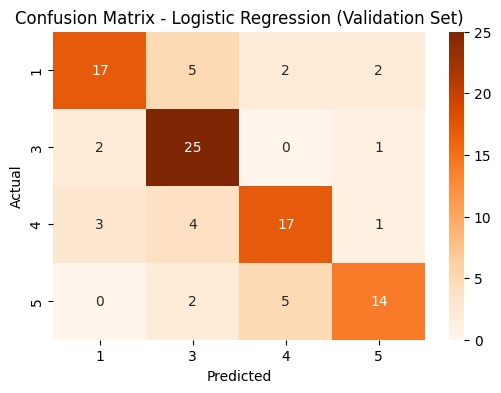

In [4]:
# =========================================
# Coral Regime - External Validation Check
# =========================================

# Load validation dataset
val_df = pd.read_csv("validation.txt", sep='\t', low_memory=False)
val_df = val_df.replace(',', '.', regex=True)

for col in val_df.columns:
    val_df[col] = pd.to_numeric(val_df[col], errors='ignore')

# Create Regime_Label
regime_cols = [c for c in val_df.columns if c.lower().startswith('regime')]

def get_regime_label_keepall(row):
    for i, c in enumerate(regime_cols, start=1):
        try:
            if float(row[c]) == 1:
                return i
        except:
            continue
    return 0

val_df['Regime_Label'] = val_df.apply(get_regime_label_keepall, axis=1)

# Prepare features
drop_cols = ['id_spatial', 'Island'] + regime_cols + ['Regime_Label']
drop_cols = [c for c in drop_cols if c in val_df.columns]

X_val = val_df.drop(columns=drop_cols, errors='ignore').select_dtypes(include=[np.number])
y_val = val_df['Regime_Label']

# Apply same imputer and scaler as training
X_val = imputer.transform(X_val)
X_val = scaler.transform(X_val)

# Predict on validation data
y_val_pred = lr.predict(X_val)

print("\n==========================")
print("Logistic Regression - Validation Set Results")
print("==========================")
print("Accuracy:", round(accuracy_score(y_val, y_val_pred), 3))
print("\nClassification Report:\n", classification_report(y_val, y_val_pred, zero_division=0))

cm_val = confusion_matrix(y_val, y_val_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm_val, annot=True, fmt='d', cmap='Oranges',
            xticklabels=np.unique(y_val), yticklabels=np.unique(y_val))
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression (Validation Set)")
plt.show()


C:\Users\Puneeth\AppData\Local\Temp\ipykernel_22176\67963666.py:23: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[col] = pd.to_numeric(df[col], errors='ignore')
C:\Users\Puneeth\AppData\Local\Temp\ipykernel_22176\67963666.py:23: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[col] = pd.to_numeric(df[col], errors='ignore')
C:\Users\Puneeth\AppData\Local\Temp\ipykernel_22176\67963666.py:23: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[col] = pd.to_numeric(df[col], errors='ignore')


✅ Train: (396, 39), Test: (124, 39), Validation: (100, 39)
Fitting 5 folds for each of 64 candidates, totalling 320 fits


c:\Users\Puneeth\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_validation.py:516: FitFailedWarning: 
80 fits failed out of a total of 320.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
80 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\Puneeth\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\Puneeth\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py", line 1365, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Punee


Best Parameters from GridSearchCV:
{'C': 0.1, 'class_weight': 'balanced', 'multi_class': 'multinomial', 'penalty': 'l2', 'solver': 'saga'}
Best Cross-Validation Accuracy: 0.7829

===== VALIDATION Set =====
Accuracy: 0.75
Micro F1: 0.75
Classification Report:
               precision    recall  f1-score   support

           1       0.74      0.65      0.69        26
           3       0.73      0.86      0.79        28
           4       0.75      0.84      0.79        25
           5       0.81      0.62      0.70        21

    accuracy                           0.75       100
   macro avg       0.76      0.74      0.74       100
weighted avg       0.75      0.75      0.75       100



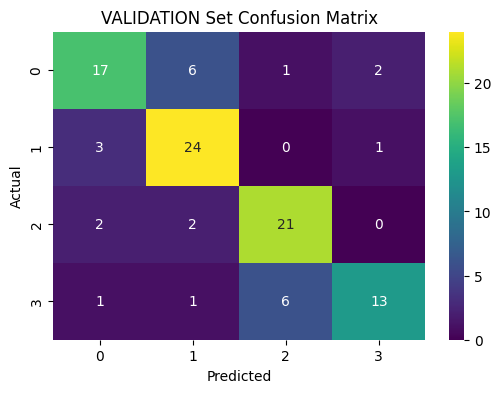

Val Accuracy:   0.7500 | F1: 0.7500


In [11]:
# =========================================
# Coral Regime — Logistic Regression with GridSearchCV
# =========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

# -----------------------------
# 1️⃣ Function to load and preprocess data
# -----------------------------
def load_dataset(path):
    df = pd.read_csv(path, sep='\t', low_memory=False)
    df = df.replace(',', '.', regex=True)
    for col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='ignore')

    regime_cols = [c for c in df.columns if c.lower().startswith('regime')]

    def get_regime_label_keepall(row):
        for i, c in enumerate(regime_cols, start=1):
            try:
                if float(row[c]) == 1:
                    return i
            except:
                continue
        return 0

    df['Regime_Label'] = df.apply(get_regime_label_keepall, axis=1)

    drop_cols = ['id_spatial', 'Island'] + regime_cols + ['Regime_Label']
    drop_cols = [c for c in drop_cols if c in df.columns]

    X = df.drop(columns=drop_cols, errors='ignore').select_dtypes(include=[np.number])
    y = df['Regime_Label']

    return X, y


# -----------------------------
# 2️⃣ Load train, test, validation datasets
# -----------------------------
X_train, y_train = load_dataset("train.txt")
X_test, y_test = load_dataset("test.txt")
X_val, y_val = load_dataset("validation.txt")

print(f"✅ Train: {X_train.shape}, Test: {X_test.shape}, Validation: {X_val.shape}")

# Align columns between all sets
all_cols = X_train.columns
X_test = X_test.reindex(columns=all_cols, fill_value=0)
X_val = X_val.reindex(columns=all_cols, fill_value=0)

# -----------------------------
# 3️⃣ Impute missing values + Scale features
# -----------------------------
imputer = SimpleImputer(strategy='mean')
scaler = StandardScaler()

X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)
X_val = imputer.transform(X_val)

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
X_val = scaler.transform(X_val)

# -----------------------------
# 4️⃣ GridSearchCV for Logistic Regression
# -----------------------------
param_grid = {
    'C': [0.0001, 0.001, 0.01, 0.1],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear', 'saga'],
    'class_weight': [None, 'balanced'],
    'multi_class': ['ovr', 'multinomial']
}

grid = GridSearchCV(lr, param_grid, cv=5, scoring='accuracy', verbose=1, n_jobs=-1)
grid.fit(X_train, y_train)

print("\n===============================")
print("Best Parameters from GridSearchCV:")
print(grid.best_params_)
print("Best Cross-Validation Accuracy:", round(grid.best_score_, 4))

# -----------------------------
# 5️⃣ Evaluate on Train, Test, and Validation
# -----------------------------
best_lr = grid.best_estimator_

def evaluate_model(model, X, y, name):
    y_pred = model.predict(X)
    acc = accuracy_score(y, y_pred)
    f1 = f1_score(y, y_pred, average='micro')
    print(f"\n===== {name} Set =====")
    print("Accuracy:", round(acc, 4))
    print("Micro F1:", round(f1, 4))
    print("Classification Report:\n", classification_report(y, y_pred, zero_division=0))
    cm = confusion_matrix(y, y_pred)
    plt.figure(figsize=(6,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='viridis')
    plt.title(f"{name} Set Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()
    return acc, f1
val_acc, val_f1 = evaluate_model(best_lr, X_val, y_val, "VALIDATION")

print(f"Val Accuracy:   {val_acc:.4f} | F1: {val_f1:.4f}")
print("===============================")


c:\Users\Puneeth\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Validation Accuracy: 0.73
Validation Micro-F1: 0.73
Validation ROC-AUC: 0.9414

Classification Report:
               precision    recall  f1-score   support

           1       0.77      0.65      0.71        26
           3       0.69      0.86      0.76        28
           4       0.72      0.72      0.72        25
           5       0.78      0.67      0.72        21

    accuracy                           0.73       100
   macro avg       0.74      0.72      0.73       100
weighted avg       0.74      0.73      0.73       100



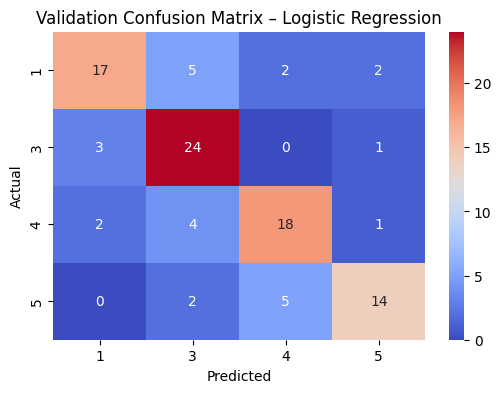

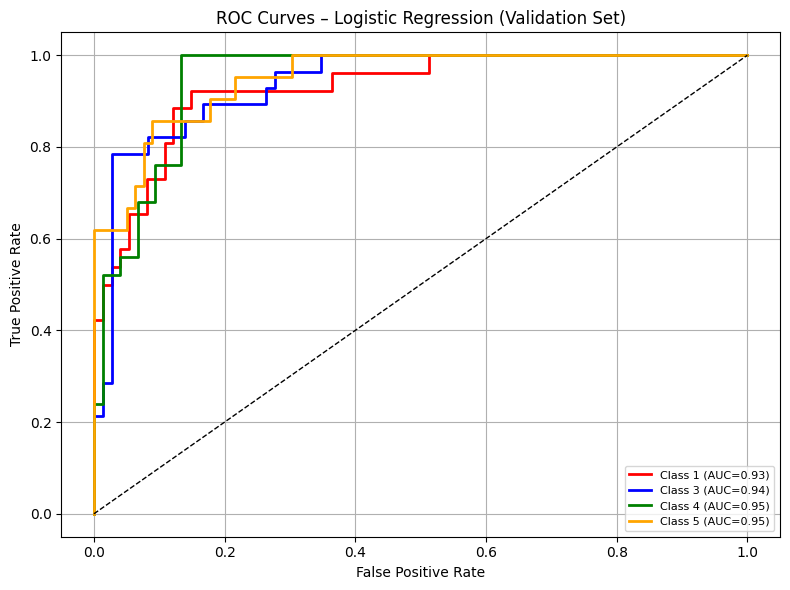

In [12]:
# ======================================================
# ⚙️ Logistic Regression Evaluation + ROC Curves (4 Classes)
# ======================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    classification_report, confusion_matrix,
    roc_curve, auc
)

# -----------------------------
# 1️⃣ Impute missing values and scale features
# -----------------------------
imputer = SimpleImputer(strategy='mean')
scaler = StandardScaler()

X_train_imp = imputer.fit_transform(X_train)
X_val_imp = imputer.transform(X_val)

X_train_scaled = scaler.fit_transform(X_train_imp)
X_val_scaled = scaler.transform(X_val_imp)

# -----------------------------
# 2️⃣ Train Logistic Regression
# -----------------------------
lr = LogisticRegression(
    max_iter=500,
    multi_class='multinomial',
    solver='lbfgs',
    class_weight='balanced',
    random_state=42
)
lr.fit(X_train_scaled, y_train)

# -----------------------------
# 3️⃣ Evaluate Predictions
# -----------------------------
y_val_pred = lr.predict(X_val_scaled)
y_val_proba = lr.predict_proba(X_val_scaled)

accuracy = accuracy_score(y_val, y_val_pred)
f1 = f1_score(y_val, y_val_pred, average='micro')
roc_auc = roc_auc_score(y_val, y_val_proba, multi_class='ovr')

print("Validation Accuracy:", round(accuracy, 4))
print("Validation Micro-F1:", round(f1, 4))
print("Validation ROC-AUC:", round(roc_auc, 4))

# -----------------------------
# 4️⃣ Classification Report + Confusion Matrix
# -----------------------------
print("\nClassification Report:\n", classification_report(y_val, y_val_pred, zero_division=0))

cm = confusion_matrix(y_val, y_val_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='coolwarm',
            xticklabels=np.unique(y_val), yticklabels=np.unique(y_val))
plt.title("Validation Confusion Matrix – Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# -----------------------------
# 5️⃣ ROC Curves for All 4 Classes
# -----------------------------
classes = np.unique(y_val)
n_classes = len(classes)
y_val_bin = label_binarize(y_val, classes=classes)

plt.figure(figsize=(8,6))
colors = ['red', 'blue', 'green', 'orange']

for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_val_bin[:, i], y_val_proba[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=colors[i], lw=2,
             label=f"Class {classes[i]} (AUC={roc_auc:.2f})")

plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.title("ROC Curves – Logistic Regression (Validation Set)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right", fontsize=8)
plt.grid(True)
plt.tight_layout()
plt.show()


In [7]:
import joblib


# Logistic Regression
joblib.dump(lr, "LR_model.pkl")


['LR_model.pkl']